In [1]:
from controller import TorqueControllerQP, TorqueControllerTraditional
from tasks import *
from run import run
from visualization import plot_cartesian_pos_errors, print_metrics

[I 09/02/26 12:40:33.504 4866] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


In [2]:
# initialize genesis
gs.init(backend=gs.cpu, logging_level="error")

### Simulation 1

We consider a simple task, consisting of three non conflicting cartesian task-space objectives.  
Task 1 is reaching a desired X, task 2 is reaching a desired Y and task 3 is following a sinusoidal trajectory in the Z coordinate.  
We do this with both the QP based controller and a traditional nullspace approach for comparison.  
We simulate gravity and we compensate for nonlinear effects.   

This experiment shows that the implementation from the paper works well and is comparable to traditional approaches in tracking performance while achieving lower total command torques.  
Nevertheless it does require significantly more computational effort. It may be possible to improve this by using a different solver.

Note that epsilon provides a way to penalize applied command torque. This is also an advantage over traditioal approach, as it gives you another tool to tweak.

In [10]:
# simulation parameters
show_viewer = False
dt = 0.01
T = 20
gravity = (0.0, 0.0, -9.81)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=20, D=10),
    YPositionTask(y_des=0.4, K=20, D=10),
    ZSinusoidalTask(z_center=0.4, amplitude=0.15, frequency=0.1, dt=dt, K=20, D=10),
]

-----------------------------
Computation time :    7.992 ms
RMS torque       :    8.897 Nm
Task 0 RMSE     :   0.0108 m
Task 0 Max Error     :   0.0214 m
Task 1 RMSE     :   0.0142 m
Task 1 Max Error     :   0.0323 m
Task 2 RMSE     :   0.0303 m
Task 2 Max Error     :   0.0466 m


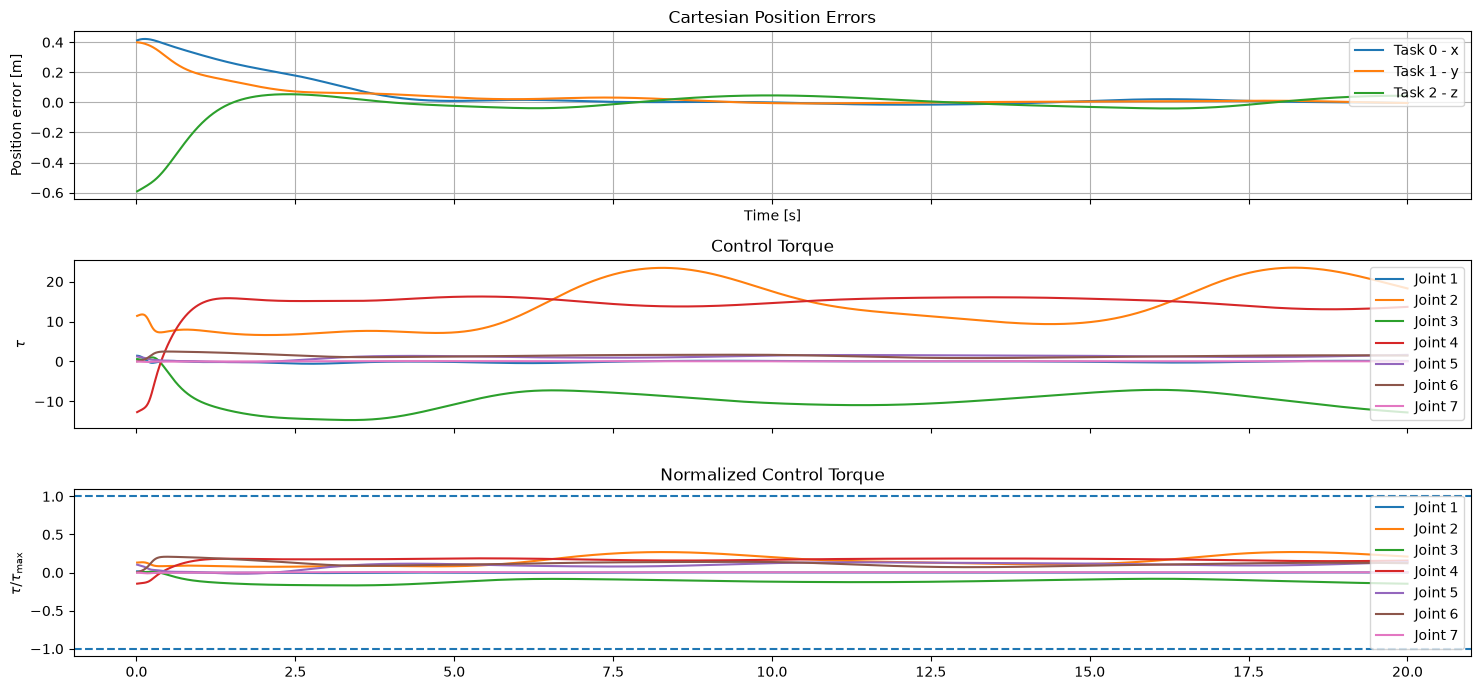

In [11]:
# QP based controller (as in the paper)

tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=None,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

-----------------------------
Computation time :    0.086 ms
RMS torque       :   16.739 Nm
Task 0 RMSE     :   0.0072 m
Task 0 Max Error     :   0.0133 m
Task 1 RMSE     :   0.0100 m
Task 1 Max Error     :   0.0230 m
Task 2 RMSE     :   0.0214 m
Task 2 Max Error     :   0.0398 m


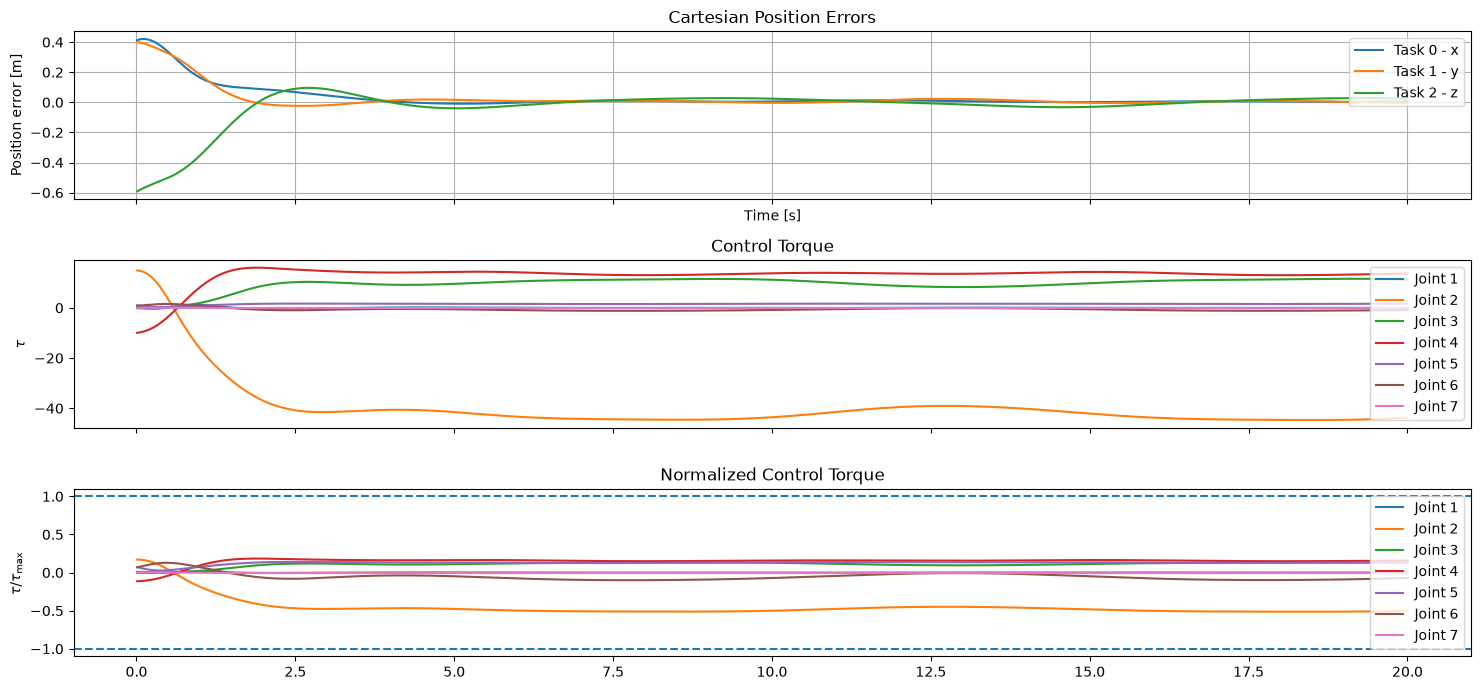

In [12]:
# traditional nullspace controller (as in the lecture)
tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=None,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

### Simulation 2

In the second simulation we consider artificial torque limits in order to showcase the QPs capability of taking torque limit constraints into account.  
We also increase the gains of the tasks to ensure the torque limits do actually get reached.

For this experiment we do not simulate gravity as this makes it easier to see the direct effects of the torque limit on the tasks themselves.

It can be seen that the QP does achieve marginally better tracking performance in this experiment compared to the traditional approach, with significantly lower maximum tracking error (after transient time). This is achieved at the expense of getting a bit less smooth trajectory of the command torque, which could potentially be fixed by improving the QP cost function.

In [13]:
# simulation parameters
show_viewer = False
dt = 0.01
T = 20
gravity = (0.0, 0.0, 0.0)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=100, D=50),
    YPositionTask(y_des=0.4, K=100, D=50),
    ZSinusoidalTask(z_center=0.4, amplitude=0.5, frequency=0.1, dt=dt, K=100, D=50),
]

# artificially limit torque
torque_limits = [8,8,8,8,8,8,8]

-----------------------------
Computation time :    7.957 ms
RMS torque       :    1.436 Nm
Task 0 RMSE     :   0.0253 m
Task 0 Max Error     :   0.0782 m
Task 1 RMSE     :   0.0144 m
Task 1 Max Error     :   0.0375 m
Task 2 RMSE     :   0.0522 m
Task 2 Max Error     :   0.1241 m


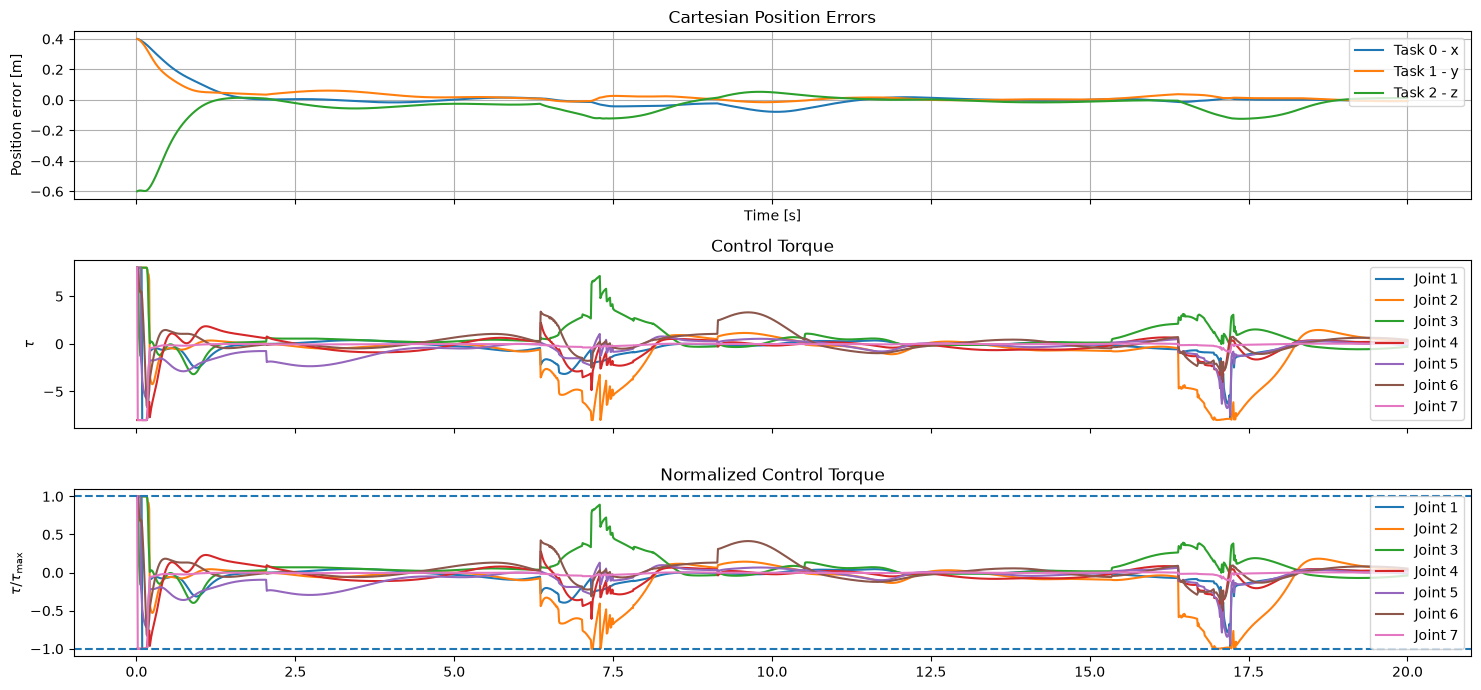

In [14]:
# QP based controller (as in the paper)

tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

-----------------------------
Computation time :    0.086 ms
RMS torque       :    1.575 Nm
Task 0 RMSE     :   0.0211 m
Task 0 Max Error     :   0.0519 m
Task 1 RMSE     :   0.0087 m
Task 1 Max Error     :   0.0221 m
Task 2 RMSE     :   0.0753 m
Task 2 Max Error     :   0.1888 m


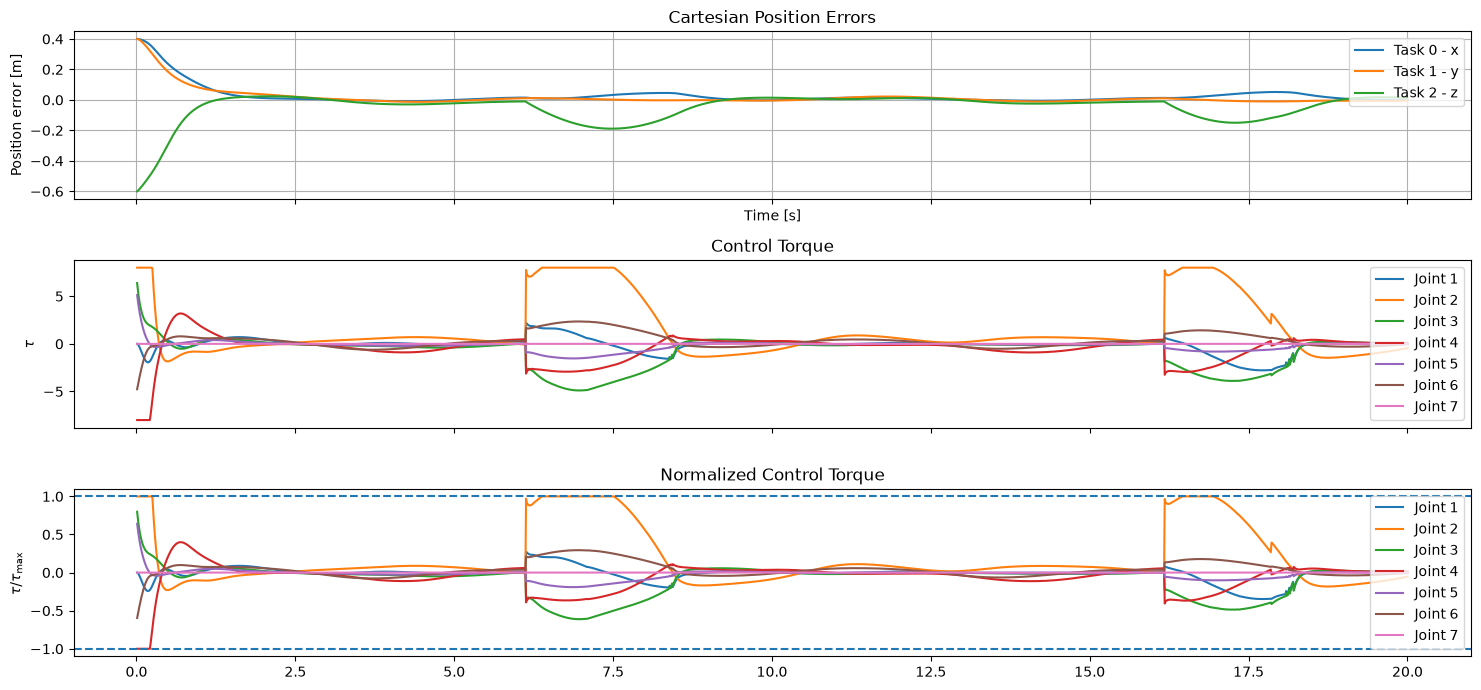

In [15]:
# traditional nullspace controller (as in the lecture)
tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=torque_limits,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

### Simulation 3

In the third simulation we consider conflicting tasks to show that the qp does strictly hold the priority. 

For simplicity reasons we just command the same task of reaching an X position with two different values twice.

We are considering gravity, compensating for nonlinear effects and not artificially limiting the maximum applicable torque.

It can be seen clearly from the residual task errors that task 1 reaches while task 2 does not. This is to be expected as task 2 directly conflicts with the higher priority task 1.

In [3]:
# simulation parameters
show_viewer = False
dt = 0.01
T = 20
gravity = (0.0, 0.0, -9.81)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4, K=20, D=10),
    XPositionTask(x_des=-0.4, K=20, D=10),
]


-----------------------------
Computation time :    5.063 ms
RMS torque       :    8.365 Nm
Task 0 RMSE     :   0.0020 m
Task 0 Max Error     :   0.0096 m
Task 1 RMSE     :   0.8006 m
Task 1 Max Error     :   0.8096 m


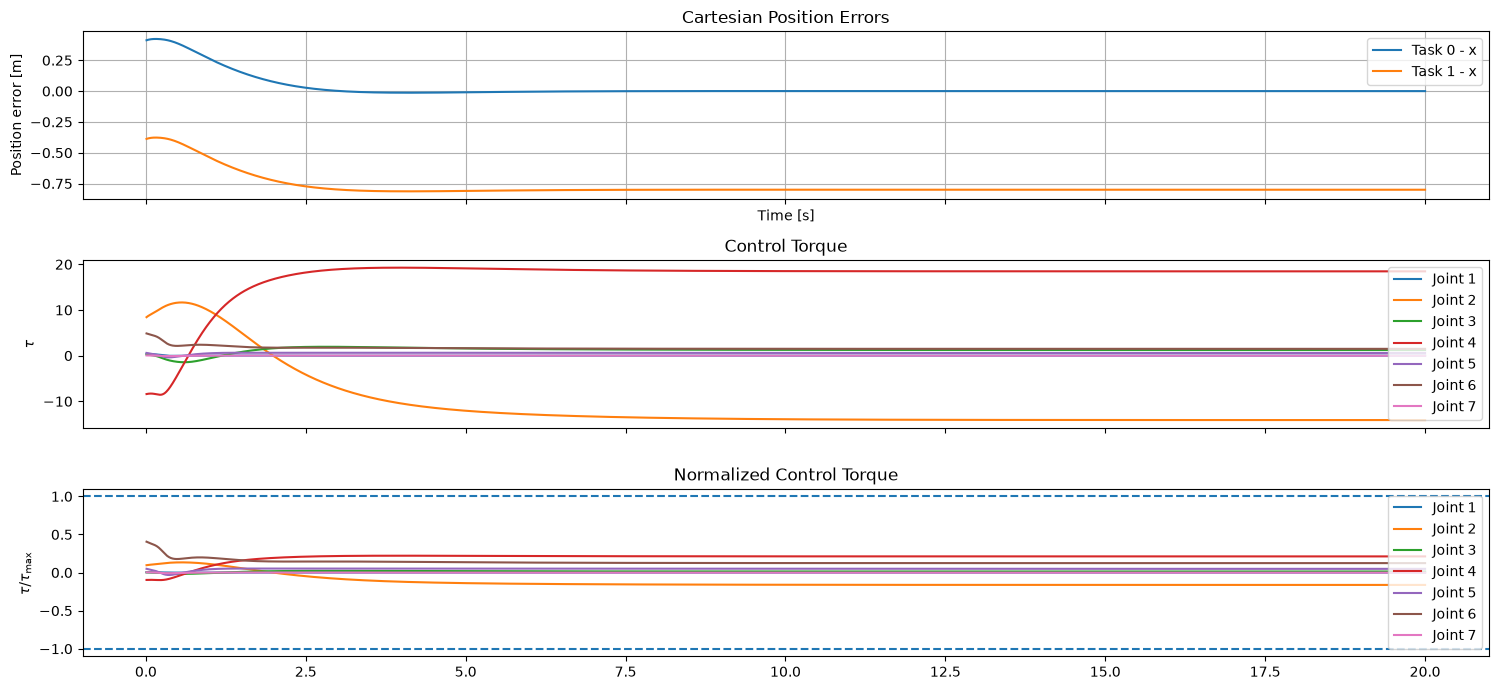

In [4]:
# QP based controller (as in the paper)

tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerQP(epsilon=1e-8),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=None,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

-----------------------------
Computation time :    0.064 ms
RMS torque       :   10.059 Nm
Task 0 RMSE     :   0.0022 m
Task 0 Max Error     :   0.0073 m
Task 1 RMSE     :   0.7992 m
Task 1 Max Error     :   0.8009 m


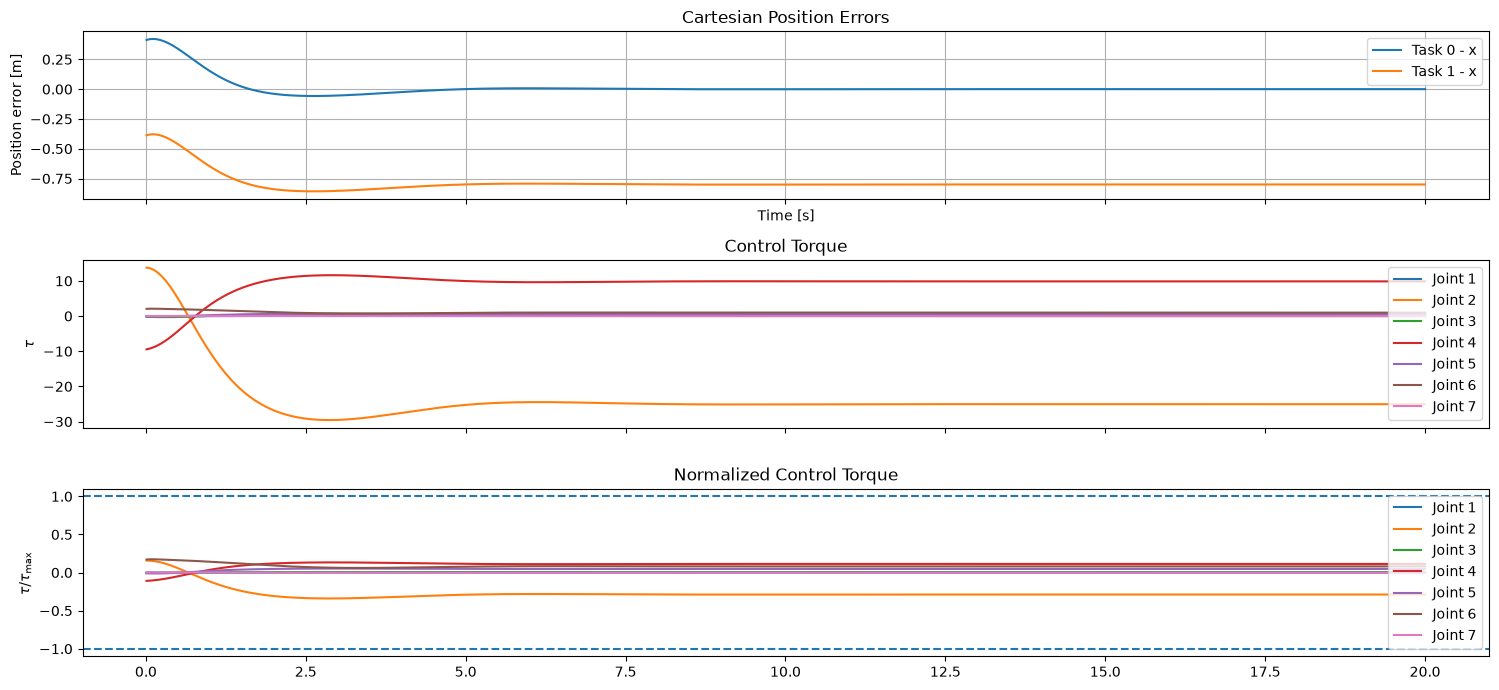

In [5]:
# traditional nullspace controller (as in the lecture)
tau_cmd_hist, tasks, torque_limits, computation_times = run(
    tasks=tasks,
    controller=TorqueControllerTraditional(),
    show_viewer=show_viewer,
    dt=dt,
    T=T,
    gravity=gravity,
    torque_limits=None,
)

print_metrics(tau_cmd_hist, tasks, computation_times, dt=0.01, transient_time=5)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)